# Attention-LSTM 土层边界检测

目标：基于 `machine_realtime_data` 中的新钻机数据，结合 `rig_layer_profile` 中的地层边界弱标签，训练模型判断一个钻机时序窗口是否接近进入不同土层。

输出不是土层名称，而是：

- `stable`: 稳定土层段
- `near_boundary`: 接近土层变化边界


In [1]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)
print("gpu count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))


torch version: 2.11.0+cu128
cuda available: True
cuda version: 12.8
gpu count: 1
gpu name: NVIDIA GeForce RTX 5070 Ti


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [3]:
torch.cuda.is_available()


True

In [4]:
import sys
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / ".env")

from src.db import get_engine

engine = get_engine()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
machine_code = "RIG-001"
project_code = "NBU-WEST-DEMO"
borehole_code = "BH-001"

rig_df = pd.read_sql(
    """
    SELECT
        timestamp,
        machine_code,
        project_code,
        borehole_code,
        drilling_depth,
        current_value,
        torque,
        penetration_speed,
        grouting_pressure,
        rotation_speed_rpm,
        mud_density_g_cm3,
        pump_flow_l_min,
        verticality_deg,
        latitude,
        longitude
    FROM machine_realtime_data
    WHERE machine_code = %(machine_code)s
      AND project_code = %(project_code)s
      AND borehole_code = %(borehole_code)s
    ORDER BY timestamp
    """,
    engine,
    params={
        "machine_code": machine_code,
        "project_code": project_code,
        "borehole_code": borehole_code,
    },
)

profile_df = pd.read_sql(
    """
    SELECT
        layer_index,
        layer_id,
        layer_name,
        top_depth_m,
        bottom_depth_m,
        engineering_group,
        expected_current_a,
        expected_torque_knm,
        expected_penetration_speed_m_min,
        expected_grouting_pressure_mpa
    FROM rig_layer_profile
    WHERE machine_code = %(machine_code)s
      AND project_code = %(project_code)s
      AND borehole_code = %(borehole_code)s
    ORDER BY layer_index
    """,
    engine,
    params={
        "machine_code": machine_code,
        "project_code": project_code,
        "borehole_code": borehole_code,
    },
)

print("rig_df:", rig_df.shape)
print("profile_df:", profile_df.shape)
display(rig_df.head())
display(profile_df)

rig_df: (54000, 15)
profile_df: (14, 10)


,timestamp,machine_code,project_code,borehole_code,drilling_depth,current_value,torque,penetration_speed,grouting_pressure,rotation_speed_rpm,mud_density_g_cm3,pump_flow_l_min,verticality_deg,latitude,longitude
0,2026-05-12 08:00:00,RIG-001,NBU-WEST-DEMO,BH-001,0.0000,146.005,56.568,0.08322,1.0979,28.648,1.1879,124.211,0.2482,29.886200,121.556799
1,2026-05-12 08:00:01,RIG-001,NBU-WEST-DEMO,BH-001,0.0013,126.508,56.424,0.08838,1.2192,28.716,1.1827,111.208,0.2201,29.886202,121.556802
2,2026-05-12 08:00:02,RIG-001,NBU-WEST-DEMO,BH-001,0.0027,126.033,48.368,0.08581,1.4308,29.285,1.1722,117.121,0.2738,29.886204,121.556799
3,2026-05-12 08:00:03,RIG-001,NBU-WEST-DEMO,BH-001,0.0040,148.137,47.666,0.09337,1.4932,28.540,1.1768,113.236,0.2619,29.886199,121.556800
4,2026-05-12 08:00:04,RIG-001,NBU-WEST-DEMO,BH-001,0.0053,127.671,57.934,0.08291,1.2541,28.199,1.1820,120.405,0.2347,29.886199,121.556800


,layer_index,layer_id,layer_name,top_depth_m,bottom_depth_m,engineering_group,expected_current_a,expected_torque_knm,expected_penetration_speed_m_min,expected_grouting_pressure_mpa
0,1,1-1,杂填土,0.00,2.10,fill,138.0,53.0,0.086,1.30
1,2,1-2,粉质黏土,2.10,3.40,cohesive,105.0,31.0,0.105,0.85
2,3,1-3,淤泥质黏土,3.40,18.10,soft_clay,77.0,17.0,0.134,0.57
3,4,3,粉砂夹粉质黏土,18.10,24.25,silty_sand,186.0,70.0,0.060,1.86
4,5,4-1,淤泥质粉质黏土,24.25,26.20,soft_silty_clay,91.0,24.0,0.122,0.71
5,6,4-2,黏土,26.20,30.25,clay,116.0,37.0,0.096,0.95
6,7,5-1,粉质黏土,30.25,38.25,cohesive,115.0,36.0,0.100,0.91
7,8,5-2,粉质黏土夹粉土,38.25,43.85,silty_clay,146.0,51.0,0.081,1.28
8,9,6-1,粉质黏土,43.85,54.20,cohesive,113.0,35.0,0.101,0.90
9,10,6-2,粉砂夹粉质黏土,54.20,55.50,silty_sand,192.0,73.0,0.058,1.92


In [6]:
feature_cols = [
    "current_value",
    "torque",
    "penetration_speed",
    "grouting_pressure",
    "rotation_speed_rpm",
    "mud_density_g_cm3",
    "pump_flow_l_min",
    "verticality_deg",
]

df = rig_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.dropna(subset=["timestamp", "drilling_depth"]).copy()

for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].interpolate().ffill().bfill()

df = df.sort_values("timestamp").reset_index(drop=True)

dri_cols = ["current_value", "torque", "grouting_pressure", "penetration_speed"]
dri_values = df[dri_cols]
dri_z = (dri_values - dri_values.mean()) / dri_values.std(ddof=0).replace(0, 1)
df["DRI"] = (
    0.30 * dri_z["current_value"]
    + 0.30 * dri_z["torque"]
    + 0.25 * dri_z["grouting_pressure"]
    - 0.15 * dri_z["penetration_speed"]
)

print(df.shape)
display(df[["timestamp", "drilling_depth", *feature_cols, "DRI"]].head())

(54000, 16)


,timestamp,drilling_depth,current_value,torque,penetration_speed,grouting_pressure,rotation_speed_rpm,mud_density_g_cm3,pump_flow_l_min,verticality_deg,DRI
0,2026-05-12 08:00:00,0.0000,146.005,56.568,0.08322,1.0979,28.648,1.1879,124.211,0.2482,0.155151
1,2026-05-12 08:00:01,0.0013,126.508,56.424,0.08838,1.2192,28.716,1.1827,111.208,0.2201,0.054795
2,2026-05-12 08:00:02,0.0027,126.033,48.368,0.08581,1.4308,29.285,1.1722,117.121,0.2738,0.054737
3,2026-05-12 08:00:03,0.0040,148.137,47.666,0.09337,1.4932,28.540,1.1768,113.236,0.2619,0.171051
4,2026-05-12 08:00:04,0.0053,127.671,57.934,0.08291,1.2541,28.199,1.1820,120.405,0.2347,0.126470


In [7]:
# 根据 profile 准备边界深度。
# 注意：这里不再直接用“中心点距离边界”生成序列标签，
# 后面会用“窗口是否跨越边界”生成标签，更适合 LSTM 时序窗口。
boundary_depths = sorted(profile_df["bottom_depth_m"].dropna().astype(float).tolist())
boundary_depths = [
    b for b in boundary_depths
    if b > df["drilling_depth"].min() and b < df["drilling_depth"].max()
]

def nearest_boundary_distance(depth):
    return min(abs(depth - b) for b in boundary_depths)

df["distance_to_boundary_m"] = df["drilling_depth"].apply(nearest_boundary_distance)

display(pd.DataFrame({"boundary_depth_m": boundary_depths}))
display(df["distance_to_boundary_m"].describe())


,boundary_depth_m
0,2.10
1,3.40
2,18.10
3,24.25
4,26.20
5,30.25
6,38.25
7,43.85
8,54.20
9,55.50


count    54000.000000
mean         1.920815
std          1.587959
min          0.000000
25%          0.661450
50%          1.520700
75%          2.758100
max          7.350000
Name: distance_to_boundary_m, dtype: float64

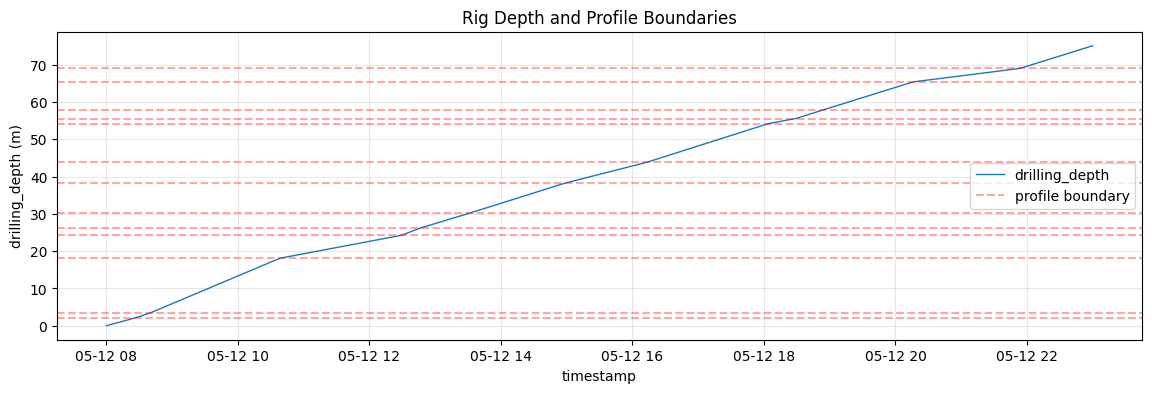

In [8]:
plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["drilling_depth"], linewidth=1, label="drilling_depth")
for i, b in enumerate(boundary_depths):
    near = df.iloc[(df["drilling_depth"] - b).abs().argsort()[:1]]
    if not near.empty:
        plt.axhline(b, color="red", linestyle="--", alpha=0.35, label="profile boundary" if i == 0 else None)
plt.xlabel("timestamp")
plt.ylabel("drilling_depth (m)")
plt.title("Rig Depth and Profile Boundaries")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [9]:
# 构造滑动窗口序列样本。
# 改进点：用“窗口是否跨越地层边界”作为 near_boundary 标签。
# 这样比只看窗口中心点是否接近边界更符合 LSTM 的输入形式。
sequence_features = [
    "current_value",
    "torque",
    "penetration_speed",
    "grouting_pressure",
    "rotation_speed_rpm",
    "mud_density_g_cm3",
    "pump_flow_l_min",
    "verticality_deg",
    "DRI",
]

scaled_df = df.copy()
scaler = StandardScaler()
scaled_df[sequence_features] = scaler.fit_transform(scaled_df[sequence_features])


def create_sequences(data, feature_cols, boundaries, window_size=60, step_size=10, negative_margin_m=1.20):
    X_seq = []
    y_seq = []
    meta = []

    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        center = start + window_size // 2
        window = data.iloc[start:end]

        depth_start = window["drilling_depth"].min()
        depth_end = window["drilling_depth"].max()
        depth_center = data["drilling_depth"].iloc[center]
        distance_to_boundary = min(abs(depth_center - b) for b in boundaries)

        crosses_boundary = any(depth_start <= b <= depth_end for b in boundaries)

        if crosses_boundary:
            label = 1
        elif distance_to_boundary >= negative_margin_m:
            label = 0
        else:
            # 靠近边界但窗口没有真正跨越边界，标签不稳定，丢弃。
            continue

        X_seq.append(window[feature_cols].values.astype(np.float32))
        y_seq.append(label)
        meta.append({
            "timestamp_center": data["timestamp"].iloc[center],
            "depth_start": depth_start,
            "depth_end": depth_end,
            "depth_center": depth_center,
            "distance_to_boundary_m": distance_to_boundary,
            "crosses_boundary": crosses_boundary,
            "label": label,
        })

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.int64), pd.DataFrame(meta)


X_seq, y_seq, meta_df = create_sequences(
    scaled_df,
    sequence_features,
    boundary_depths,
    window_size=60,
    step_size=10,
    negative_margin_m=1.20,
)

print("X_seq:", X_seq.shape)
print("y_seq:", y_seq.shape)
display(pd.Series(y_seq).value_counts().rename(index={0: "stable", 1: "near_boundary"}))
display(meta_df.head())


X_seq: (3244, 60, 9)
y_seq: (3244,)


stable           3165
near_boundary      79
Name: count, dtype: int64

,timestamp_center,depth_start,depth_end,depth_center,distance_to_boundary_m,crosses_boundary,label
0,2026-05-12 08:00:30,0.0000,0.0783,0.0398,2.0602,False,0
1,2026-05-12 08:00:40,0.0133,0.0915,0.0531,2.0469,False,0
2,2026-05-12 08:00:50,0.0265,0.1048,0.0663,2.0337,False,0
3,2026-05-12 08:01:00,0.0398,0.1181,0.0796,2.0204,False,0
4,2026-05-12 08:01:10,0.0531,0.1313,0.0929,2.0071,False,0


In [10]:
# 先用分层随机划分做 baseline，确认模型能否学到边界信号。
# 注意：这会有一定相邻窗口泄漏；等模型稳定后，再做更严格的按深度分段验证。
idx = np.arange(len(X_seq))

train_idx, temp_idx, y_train, y_temp = train_test_split(
    idx,
    y_seq,
    test_size=0.30,
    random_state=SEED,
    stratify=y_seq,
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

X_train = X_seq[train_idx]
X_val = X_seq[val_idx]
X_test = X_seq[test_idx]

meta_train = meta_df.iloc[train_idx].reset_index(drop=True)
meta_val = meta_df.iloc[val_idx].reset_index(drop=True)
meta_test = meta_df.iloc[test_idx].reset_index(drop=True)

print("train:", X_train.shape, pd.Series(y_train).value_counts().to_dict())
print("val:", X_val.shape, pd.Series(y_val).value_counts().to_dict())
print("test:", X_test.shape, pd.Series(y_test).value_counts().to_dict())


train: (2270, 60, 9) {0: 2215, 1: 55}
val: (487, 60, 9) {0: 475, 1: 12}
test: (487, 60, 9) {0: 475, 1: 12}


In [11]:
class RigSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 256
train_loader = DataLoader(RigSequenceDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(RigSequenceDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(RigSequenceDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

class AttentionLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_classes=2, dropout=0.30):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.attention_fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attention_scores = self.attention_fc(lstm_out)
        attention_weights = torch.softmax(attention_scores, dim=1)
        context = torch.sum(attention_weights * lstm_out, dim=1)
        logits = self.classifier(self.dropout(context))
        return logits, attention_weights

model = AttentionLSTM(input_dim=X_seq.shape[2]).to(device)

class_counts = np.bincount(y_train, minlength=2)
class_weights = class_counts.sum() / np.maximum(class_counts, 1)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
model


AttentionLSTM(
  (lstm): LSTM(9, 32, batch_first=True)
  (attention_fc): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)

In [12]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    preds_all, labels_all = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds_all.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
        labels_all.extend(y_batch.detach().cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(labels_all, preds_all)

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    preds_all, labels_all, prob_all = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits, _ = model(X_batch)
            loss = criterion(logits, y_batch)
            prob = torch.softmax(logits, dim=1)[:, 1]

            total_loss += loss.item() * X_batch.size(0)
            preds_all.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            labels_all.extend(y_batch.detach().cpu().numpy())
            prob_all.extend(prob.detach().cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(labels_all, preds_all), np.array(labels_all), np.array(preds_all), np.array(prob_all)

In [20]:
num_epochs = 300
patience = 6
best_val_loss = float("inf")
bad_epochs = 0
best_model_path = PROJECT_ROOT / "src/ml/saved_models/attention_lstm_boundary_rig001_v2.pt"
best_model_path.parent.mkdir(parents=True, exist_ok=True)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        bad_epochs += 1

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"bad_epochs={bad_epochs}"
    )

    if bad_epochs >= patience:
        print(f"Early stopping at epoch {epoch}; best_val_loss={best_val_loss:.4f}")
        break


Epoch 001 | train_loss=0.5610 train_acc=0.6789 | val_loss=0.5701 val_acc=0.6653 | bad_epochs=0
Epoch 002 | train_loss=0.5793 train_acc=0.6767 | val_loss=0.5476 val_acc=0.6632 | bad_epochs=0
Epoch 003 | train_loss=0.5580 train_acc=0.6727 | val_loss=0.5425 val_acc=0.6632 | bad_epochs=0
Epoch 004 | train_loss=0.5507 train_acc=0.6749 | val_loss=0.5581 val_acc=0.6653 | bad_epochs=1
Epoch 005 | train_loss=0.5632 train_acc=0.6797 | val_loss=0.5542 val_acc=0.6653 | bad_epochs=2
Epoch 006 | train_loss=0.5548 train_acc=0.6802 | val_loss=0.5488 val_acc=0.6632 | bad_epochs=3
Epoch 007 | train_loss=0.5431 train_acc=0.6797 | val_loss=0.5442 val_acc=0.6632 | bad_epochs=4
Epoch 008 | train_loss=0.5369 train_acc=0.6793 | val_loss=0.5402 val_acc=0.6674 | bad_epochs=0
Epoch 009 | train_loss=0.5330 train_acc=0.6793 | val_loss=0.5384 val_acc=0.6674 | bad_epochs=0
Epoch 010 | train_loss=0.5360 train_acc=0.6833 | val_loss=0.5349 val_acc=0.6674 | bad_epochs=0
Epoch 011 | train_loss=0.5323 train_acc=0.6833 | v

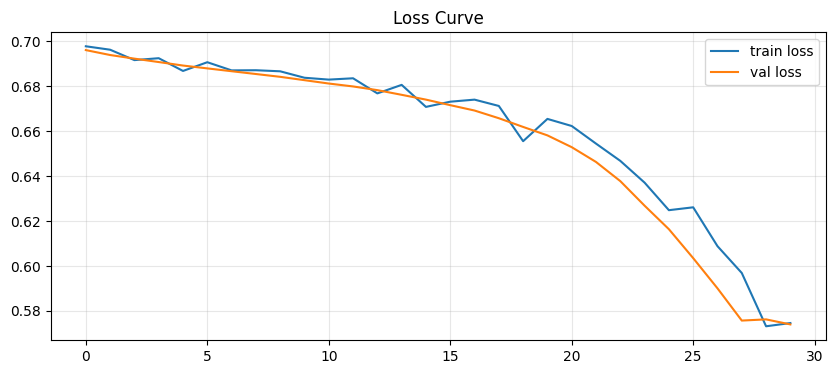

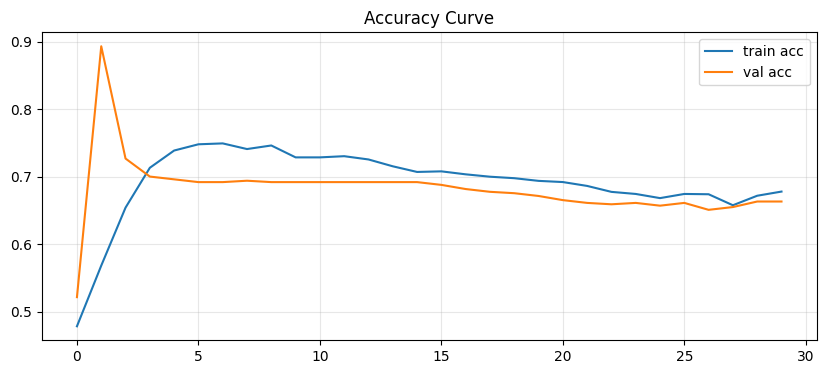

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Accuracy Curve")
plt.show()

test_loss: 0.6454479602572855
test_acc: 0.6591375770020534
               precision    recall  f1-score   support

       stable       0.98      0.66      0.79       475
near_boundary       0.04      0.58      0.08        12

     accuracy                           0.66       487
    macro avg       0.51      0.62      0.43       487
 weighted avg       0.96      0.66      0.77       487



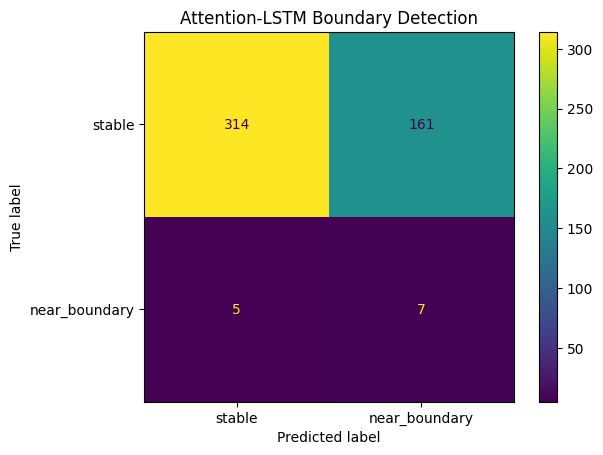

In [15]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader)

print("test_loss:", test_loss)
print("test_acc:", test_acc)
print(classification_report(y_true, y_pred, target_names=["stable", "near_boundary"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["stable", "near_boundary"])
disp.plot()
plt.title("Attention-LSTM Boundary Detection")
plt.show()

In [16]:
# 对完整序列做滑窗预测，输出 near_boundary 概率曲线。
def create_all_sequences(data, feature_cols, window_size=60, step_size=10):
    X_all = []
    meta = []
    for start in range(0, len(data) - window_size + 1, step_size):
        end = start + window_size
        center = start + window_size // 2
        window = data.iloc[start:end]
        depth_start = window["drilling_depth"].min()
        depth_end = window["drilling_depth"].max()
        depth_center = data["drilling_depth"].iloc[center]
        X_all.append(window[feature_cols].values.astype(np.float32))
        meta.append({
            "timestamp_center": data["timestamp"].iloc[center],
            "depth_start": depth_start,
            "depth_end": depth_end,
            "depth_center": depth_center,
            "distance_to_boundary_m": data["distance_to_boundary_m"].iloc[center],
        })
    return np.array(X_all, dtype=np.float32), pd.DataFrame(meta)

X_all, all_meta = create_all_sequences(scaled_df, sequence_features, window_size=60, step_size=10)
all_loader = DataLoader(RigSequenceDataset(X_all, np.zeros(len(X_all), dtype=np.int64)), batch_size=256, shuffle=False)

model.eval()
probs = []
with torch.no_grad():
    for X_batch, _ in all_loader:
        logits, _ = model(X_batch.to(device))
        probs.extend(torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())

boundary_prob_df = all_meta.copy()
boundary_prob_df["near_boundary_prob"] = probs
display(boundary_prob_df.head())


,timestamp_center,depth_start,depth_end,depth_center,distance_to_boundary_m,near_boundary_prob
0,2026-05-12 08:00:30,0.0000,0.0783,0.0398,2.0602,0.689260
1,2026-05-12 08:00:40,0.0133,0.0915,0.0531,2.0469,0.687731
2,2026-05-12 08:00:50,0.0265,0.1048,0.0663,2.0337,0.686618
3,2026-05-12 08:01:00,0.0398,0.1181,0.0796,2.0204,0.686194
4,2026-05-12 08:01:10,0.0531,0.1313,0.0929,2.0071,0.686095


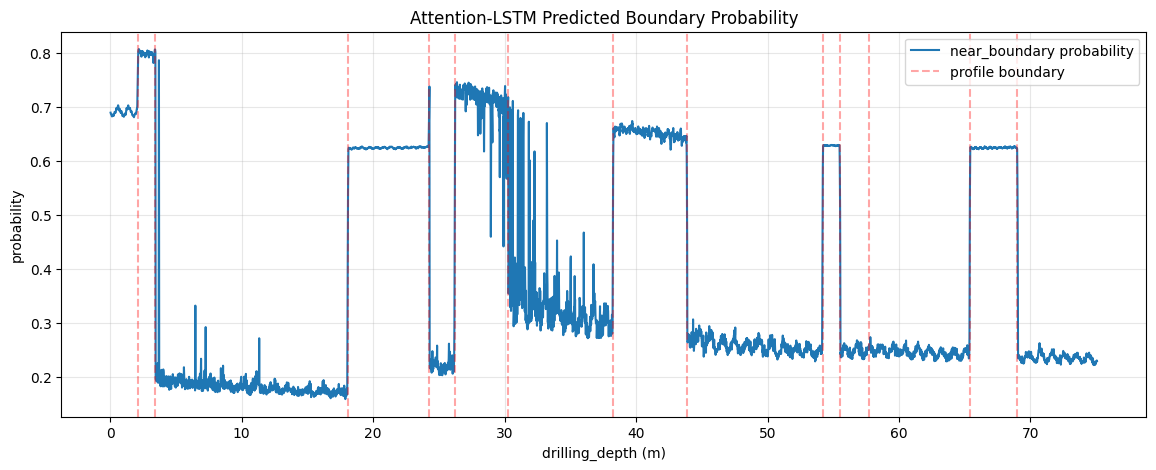

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(boundary_prob_df["depth_center"], boundary_prob_df["near_boundary_prob"], label="near_boundary probability")
for i, b in enumerate(boundary_depths):
    plt.axvline(b, color="red", linestyle="--", alpha=0.35, label="profile boundary" if i == 0 else None)
plt.xlabel("drilling_depth (m)")
plt.ylabel("probability")
plt.title("Attention-LSTM Predicted Boundary Probability")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [18]:
# 从概率曲线中提取边界峰值。
# 如果候选太少，降低 prob_threshold；如果候选太多，提高它。
prob_threshold = 0.50
min_gap_m = 0.8

candidate = boundary_prob_df[boundary_prob_df["near_boundary_prob"] >= prob_threshold].copy()
boundary_rows = []

for _, row in candidate.sort_values("depth_center").iterrows():
    depth = row["depth_center"]
    if not boundary_rows:
        boundary_rows.append(row)
        continue
    last_depth = boundary_rows[-1]["depth_center"]
    if depth - last_depth < min_gap_m:
        if row["near_boundary_prob"] > boundary_rows[-1]["near_boundary_prob"]:
            boundary_rows[-1] = row
    else:
        boundary_rows.append(row)

predicted_boundaries_df = pd.DataFrame(boundary_rows)
if not predicted_boundaries_df.empty:
    predicted_boundaries_df = predicted_boundaries_df[["depth_center", "near_boundary_prob"]].rename(columns={"depth_center": "predicted_boundary_depth"}).reset_index(drop=True)

display(predicted_boundaries_df)


,predicted_boundary_depth,near_boundary_prob
0,0.6102,0.702947
1,2.1908,0.807063
2,3.4269,0.806367
3,19.1622,0.626611
4,21.4197,0.626393
5,22.5670,0.626674
6,24.2876,0.737690
7,26.3821,0.745702
8,27.2706,0.744810
9,28.6774,0.736532


In [19]:
comparison_rows = []
for detected in predicted_boundaries_df["predicted_boundary_depth"]:
    nearest = min(boundary_depths, key=lambda x: abs(x - detected))
    comparison_rows.append({
        "predicted_boundary_depth": detected,
        "nearest_profile_boundary_depth": nearest,
        "offset_m": detected - nearest,
        "abs_offset_m": abs(detected - nearest),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
print("mean abs offset:", comparison_df["abs_offset_m"].mean() if not comparison_df.empty else None)

,predicted_boundary_depth,nearest_profile_boundary_depth,offset_m,abs_offset_m
0,0.6102,2.10,-1.4898,1.4898
1,2.1908,2.10,0.0908,0.0908
2,3.4269,3.40,0.0269,0.0269
3,19.1622,18.10,1.0622,1.0622
4,21.4197,24.25,-2.8303,2.8303
5,22.5670,24.25,-1.6830,1.6830
6,24.2876,24.25,0.0376,0.0376
7,26.3821,26.20,0.1821,0.1821
8,27.2706,26.20,1.0706,1.0706
9,28.6774,30.25,-1.5726,1.5726


mean abs offset: 1.0396409090909096
